In [ ]:
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

### Plotting Functions

we start from the slide 28, with the set of parameters, from the differential equations for the firing rate of the excitatory population and the inibitory. all the weights, the time constant for the two populations and also the current that is arriving on them.

In [ ]:
def plot_FI_inverse(x, a, theta): #PLOTTING OF THE INVERSE ACTIVATION FUNCTION OF A NEURAL POPULATION. 
   # A AND THETA ARE THE PARAMETERS. IN THE WILSON-COWAN MODEL THE ACTIVAtion function determines the 
   # firing rate of a population based on its input. 
    """  
    Plot the inverse of the activation function
    """
    f, ax = plt.subplots()
    ax.plot(x, F_inv(x, a=a, theta=theta))
    ax.set(xlabel="$x$", ylabel="$F^{-1}(x)$")


def plot_FI_EI(x, FI_exc, FI_inh): #this plots the firing rate functions for both the excitation and 
    #the inibhition populations, using two different sets of firing-rate data. 
    #the excitatory population increases activity, while the inhibitory one suppresses it. 
    """
    Plot the activation fuction for the E and I populations
    """
    plt.figure()
    plt.plot(x, FI_exc, 'b', label='E population')
    plt.plot(x, FI_inh, 'r', label='I population')
    plt.legend(loc='lower right')
    plt.xlabel('x (a.u.)')
    plt.ylabel('F(x)')
    plt.show()


def my_test_plot(t, rE1, rI1, rE2, rI2): #helps visualizing how the activity 
    #of both populations over time evolves and how different initial conditions 
    # can lead to different dynamic behaviors. 
    """
    Plot activities of E and I population for two different initial conditions
    """

    plt.figure()
    ax1 = plt.subplot(211)
    ax1.plot(pars['range_t'], rE1, 'b', label='E population')
    ax1.plot(pars['range_t'], rI1, 'r', label='I population')
    ax1.set_ylabel('Activity')
    ax1.legend(loc='best')

    ax2 = plt.subplot(212, sharex=ax1, sharey=ax1)
    ax2.plot(pars['range_t'], rE2, 'b', label='E population')
    ax2.plot(pars['range_t'], rI2, 'r', label='I population')
    ax2.set_xlabel('t (ms)')
    ax2.set_ylabel('Activity')
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()


def plot_nullclines(Exc_null_rE, Exc_null_rI, Inh_null_rE, Inh_null_rI): #plot nullclines for the excitatory and 
    #inhibitory populations in the phase plane. 
    #nullclines represent points in the phase plane where the rate of change of one population E or I is zero.
    #in the Wilson Cowan model, these show the equilibirum points where the system can potentially settle. 
    """
    Plot nullclines in the phase plane for both drE and drI
    """

    plt.figure()
    plt.plot(Exc_null_rE, Exc_null_rI, 'b', label='E nullcline')
    plt.plot(Inh_null_rE, Inh_null_rI, 'r', label='I nullcline')
    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')
    plt.legend(loc='best')
    plt.show()


def my_plot_nullcline(pars): #This function generates the nullclines for both the excitory and inhibitory 
    #populations, using parameter values provided in pars.
    """
    Plot nullclines in the phase plane for both drE and drI
    """
    Exc_null_rE = np.linspace(-0.01, 0.96, 100)
    Exc_null_rI = get_E_nullcline(Exc_null_rE, **pars)
    Inh_null_rI = np.linspace(-.01, 0.8, 100)
    Inh_null_rE = get_I_nullcline(Inh_null_rI, **pars)

    plt.plot(Exc_null_rE, Exc_null_rI, 'b', label='E nullcline')
    plt.plot(Inh_null_rE, Inh_null_rI, 'r', label='I nullcline')
    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')
    plt.legend(loc='best')


def my_plot_vector(pars, my_n_skip=2, myscale=5): #This function visualizes the vector field in the phase
    #plane by plotting arrows that show the direction and magnitude of change for the populations (E and I).
    """
    Plot arrows of the vector field in the phase plane
    """
    EI_grid = np.linspace(0., 1., 20)
    rE, rI = np.meshgrid(EI_grid, EI_grid)
    drEdt, drIdt = EIderivs(rE, rI, **pars)
    n_skip = my_n_skip
    # plot of the arrows (with slicing)
    plt.quiver(rE[::n_skip, ::n_skip], rI[::n_skip, ::n_skip],
             drEdt[::n_skip, ::n_skip], drIdt[::n_skip, ::n_skip],
             angles='xy', scale_units='xy', scale=myscale, facecolor='c')

    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')


def my_plot_trajectory(pars, mycolor, x_init, mylabel): #This function simulates and plots multiple trajectories 
    #for different initial conditions in the phase plane.
    # This helps you see the variety of trajectories that the system can take from different initial conditions.
    """
    Plot a single trajectory in the phase plane, given the initial conditions
    """
    pars = pars.copy()
    pars['rE_init'], pars['rI_init'] = x_init[0], x_init[1]
    rE_tj, rI_tj = simulate_wc(**pars)

    plt.plot(rE_tj, rI_tj, color=mycolor, label=mylabel)
    plt.plot(x_init[0], x_init[1], 'o', color=mycolor, ms=8)
    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')


def my_plot_trajectories(pars, dx, n, mylabel):
    """
    Solve for I along the E_grid from dE/dt = 0.

    Expects:
    pars    : Parameter dictionary
    dx      : increment of initial values
    n       : n*n trjectories
    mylabel : label for legend

    Returns: Figure of trajectories
    """

    pars = pars.copy()
    for ie in range(n):
        for ii in range(n):
            pars['rE_init'], pars['rI_init'] = dx * ie, dx * ii
            rE_tj, rI_tj = simulate_wc(**pars)
            if (ie == n-1) & (ii == n-1):
                plt.plot(rE_tj, rI_tj, 'gray', alpha=0.8, label=mylabel)
            else:
                plt.plot(rE_tj, rI_tj, 'gray', alpha=0.8)
    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')


def plot_complete_analysis(pars): #This function provides a comprehensive plot that includes:
#Trajectories for different initial conditions.
#The nullclines for the E and I populations.
#The vector field showing system dynamics.
#Context: It’s a complete analysis of the phase plane, useful for understanding the system's stability 
# and behavior under different initial conditions and parameter values.
    """
    Plot trajectories for differen initial conditions and vector field in the phase plane
    """
    plt.figure(figsize=(7.7, 6.))

    # plot example trajectories
    my_plot_trajectories(pars, 0.2, 6,
                       'Sample trajectories \nfor different init. conditions')
    my_plot_trajectory(pars, 'orange', [0.6, 0.8],
                     'Sample trajectory for \nlow activity')
    my_plot_trajectory(pars, 'm', [0.6, 0.6],
                     'Sample trajectory for \nhigh activity')

    # plot nullclines
    my_plot_nullcline(pars)

    # plot vector field
    EI_grid = np.linspace(0., 1., 20)
    rE, rI = np.meshgrid(EI_grid, EI_grid)
    drEdt, drIdt = EIderivs(rE, rI, **pars)
    n_skip = 2
    plt.quiver(rE[::n_skip, ::n_skip], rI[::n_skip, ::n_skip],
             drEdt[::n_skip, ::n_skip], drIdt[::n_skip, ::n_skip],
             angles='xy', scale_units='xy', scale=5., facecolor='c')

    plt.legend(loc=[1.02, 0.57], handlelength=1)
    plt.show()


def plot_fp(x_fp, position=(0.02, 0.1), rotation=0): #This plots a fixed point in the phase plane and labels it.
#Context: A fixed point represents a stable state where the system doesn't change. This is important for understanding 
# #where the system could settle under certain conditions.

    """
    Plot fixed point in the phase plane
    """
    plt.plot(x_fp[0], x_fp[1], 'ko', ms=8)
    plt.text(x_fp[0] + position[0], x_fp[1] + position[1],
            f'Fixed Point=\n({x_fp[0]:.3f}, {x_fp[1]:.3f})',
            horizontalalignment='center', verticalalignment='bottom',
            rotation=rotation, fontsize='xx-small')

key concepts: Excitatory (E) and Inhibitory (I) Populations: The Wilson-Cowan model describes the interaction between two populations of neurons: excitatory (E) and inhibitory (I). These populations have opposite effects on each other's activity.
Nullclines: The nullclines represent conditions where the rate of change of the population activities (drE/dt and drI/dt) is zero. The intersection of these nullclines can show equilibrium points of the system.
Vector Field: The vector field represents the differential equations governing the dynamics. It helps visualize how the system evolves at every point in the phase plane.
Trajectory: The trajectory represents the path the system follows over time starting from a particular initial condition.
Fixed Point: A fixed point is an equilibrium state where both populations' activity remains constant.



## Helper function

In [ ]:
def default_pars(**kwargs): #This function sets up the default parameters for the Wilson-Cowan model. 
    #The parameters are mostly related to the properties 
    #of the excitatory and inhibitory populations. 
    # the parameters are: time constants (how quickly the population responds),
    #gain and threshold param,eters (determines the shape of the population's response curve), 
    #Connectivity parameters: represent the connection strengths between the populations.
    #External inputs: These can be used to apply external stimulation to the populations.
    #Simulation parameters: Total time of the simulation and the time step.
    """
    Define the parameters of the dynamical system
    """
    pars = {}

    # Excitatory parameters
    pars['tau_E'] = 1.     # Timescale of the E population [ms]
    pars['a_E'] = 1.2      # Gain of the E population
    pars['theta_E'] = 2.8  # Threshold of the E population

    # Inhibitory parameters
    pars['tau_I'] = 2.0    # Timescale of the I population [ms]
    pars['a_I'] = 1.0      # Gain of the I population
    pars['theta_I'] = 4.0  # Threshold of the I population

    # Connection strength
    pars['wEE'] = 9.   # E to E
    pars['wEI'] = 4.   # I to E
    pars['wIE'] = 13.  # E to I
    pars['wII'] = 11.  # I to I

    # External input
    pars['I_ext_E'] = 0.
    pars['I_ext_I'] = 0.

    # simulation parameters
    pars['T'] = 50.        # Total duration of simulation [ms]
    pars['dt'] = .1        # Simulation time step [ms]
    pars['rE_init'] = 0.2  # Initial value of E
    pars['rI_init'] = 0.2  # Initial value of I

    # External parameters if any
    for k in kwargs:
        pars[k] = kwargs[k]

    # Vector of discretized time points [ms]
    pars['range_t'] = np.arange(0, pars['T'], pars['dt'])

    return pars


def F(x, a, theta): #This function implements a sigmoid-like activation function that describes the response of a population to its input. It's used to model how the activity of a population 
    #is a smooth, nonlinear function of its input:
# we define the sigmoid function as F. THAT IS THE POPULATION ACITVATION FUNCTION AND DEPENDS ON THE THRESHOLD.
#WHAT WE GIVE TO IT IN INPUT IS THE ACITIVTY OF THE POPULATION.
    """
    Population activation function, F-I curve

    Args:
        x     : the population input
        a     : the gain of the function
        theta : the threshold of the function

    Returns:
        f     : the population activation response f(x) for input x
    """

    f = (1 + np.exp(-a * (x - theta)))**-1 - (1 + np.exp(a * theta))**-1

    return f


def dF(x, a, theta): #is the derivative of the sigmoid function F(x), and it represents how the population's response changes as the input changes. 
#This can be used for stability analysis or to compute the dynamics of the system.
    """
    Derivative of the population activation function.

    Args:
        x     : the population input
        a     : the gain of the function
        theta : the threshold of the function

    Returns:
        dFdx  :  Derivative of the population activation function.
    """

    dFdx = a * np.exp(-a * (x - theta)) * (1 + np.exp(-a * (x - theta)))**-2

    return dFdx


def F_inv(x, a, theta): #computes the inverse of the activation function F(x),
    #which allows you to go from the output back to the input. This is useful for finding nullclines, 
#which are curves where the derivatives of the system are zero (steady states).
    """
    Inverse of the population activation function.
    Args:
        x         : the population input
        a         : the gain of the function
        theta     : the threshold of the function

    Returns:
        F_inverse : value of the inverse function
    """

    # Calculate Finverse (ln(x) can be calculated as np.log(x))
    F_inverse = -1/a * np.log((x + (1 + np.exp(a * theta))**-1)**-1 - 1) + theta

    return F_inverse #the inverse basically is a logaritmic function, since the sigmoid is an exponential.

#DEFINITION OF THE NULLCLINES: I REAHC THIS JUST IMPOSING THESE TWO DIFFERNETIAL EQUATION = 0,
#AND THERE IS A PROBLEM: WE WANT a solution for the rate. both the rate are both in the argument of the transfer function.
#we need to build the inverse of the transfer function.
def get_E_nullcline(rE, a_E, theta_E, wEE, wEI, I_ext_E, **other_pars):
    """
    Solve for rI along the rE from drE/dt = 0.

    Args:
        rE    : response of excitatory population
        a_E, theta_E, wEE, wEI, I_ext_E : Wilson-Cowan excitatory parameters
        Other parameters are ignored

    Returns:
        rI    : values of inhibitory population along the nullcline on the rE
    """
    rI = 1 / wEI * (wEE * rE - F_inv(rE, a_E, theta_E) + I_ext_E)

    return rI


def get_I_nullcline(rI, a_I, theta_I, wIE, wII, I_ext_I, **other_pars):
    """
    Solve for E along the rI from dI/dt = 0.

    Args:
        rI    : response of inhibitory population
        a_I, theta_I, wIE, wII, I_ext_I : Wilson-Cowan inhibitory parameters
        Other parameters are ignored

    Returns:
        rE    : values of the excitatory population along the nullcline on the rI
    """
    rE = 1 / wIE * (wII * rI + F_inv(rI, a_I, theta_I) - I_ext_I)

    return rE

def EIderivs(rE, rI,tau_E, a_E, theta_E, wEE, wEI, I_ext_E,  #This function computes the time derivatives of the activity of the excitatory 
             #and inhibitory populations. It represents the dynamics of the Wilson-Cowan equations:
             tau_I, a_I, theta_I, wIE, wII, I_ext_I,
             **other_pars):
    """
    Time derivatives for E/I variables (dE/dt, dI/dt).
    """
    drEdt = (-rE + F(wEE * rE - wEI * rI + I_ext_E, a_E, theta_E)) / tau_E
    drIdt = (-rI + F(wIE * rE - wII * rI + I_ext_I, a_I, theta_I)) / tau_I

    return drEdt, drIdt



#This is the main simulation function. It solves the Wilson-Cowan equations over time using an Euler 
# #integration scheme. Given initial values for the populations and a set of parameters, it computes 
# #the time evolution of the excitatory (rE) and inhibitory (rI) populations. It returns arrays with 
# #the activities of these populations over the simulation time.
def simulate_wc(tau_E, a_E, theta_E, tau_I, a_I, theta_I,
                wEE, wEI, wIE, wII, I_ext_E, I_ext_I,
                rE_init, rI_init, dt, range_t, **other_pars):
    """
    Simulate the Wilson-Cowan equations

    Args:
        Parameters of the Wilson-Cowan model

    Returns:
        rE, rI (arrays) : Activity of excitatory and inhibitory populations
    """
    # Initialize activity arrays
    Lt = range_t.size
    rE = np.append(rE_init, np.zeros(Lt - 1))
    rI = np.append(rI_init, np.zeros(Lt - 1))
    I_ext_E = I_ext_E * np.ones(Lt)
    I_ext_I = I_ext_I * np.ones(Lt)

    # Simulate the Wilson-Cowan equations
    for k in range(Lt - 1):

        # Calculate the derivative of the E population
        drE = dt / tau_E * (-rE[k] + F(wEE * rE[k] - wEI * rI[k] + I_ext_E[k], a_E, theta_E))

        # Calculate the derivative of the I population
        drI = dt / tau_I * (-rI[k] + F(wIE * rE[k] - wII * rI[k] + I_ext_I[k],
                                   a_I, theta_I))

        # Update using Euler's method
        rE[k + 1] = rE[k] + drE
        rI[k + 1] = rI[k] + drI

    return rE, rI

## Visualize the nullclines

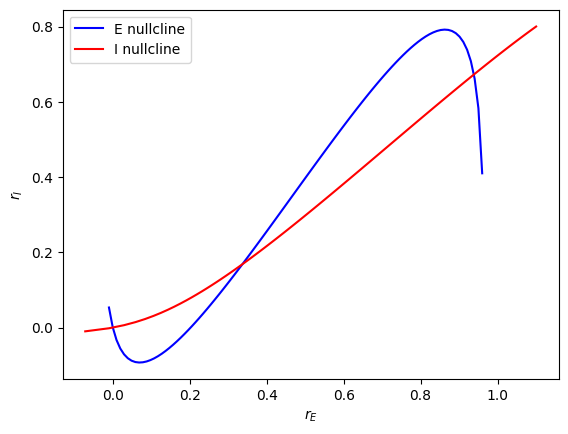

In [ ]:
# Set parameters
pars = default_pars() #initializes the parameters for your system. 
# You're defining two linear spaces:
Exc_null_rE = np.linspace(-0.01, 0.96, 100)
Inh_null_rI = np.linspace(-.01, 0.8, 100)

# Compute nullclines
Exc_null_rI = get_E_nullcline(Exc_null_rE, **pars) #computes the nullcline for the excitatory population as a function of rE.
Inh_null_rE = get_I_nullcline(Inh_null_rI, **pars) #computes the nullcline for the inhibitory population as a function of rI

plot_nullclines(Exc_null_rE, Exc_null_rI, Inh_null_rE, Inh_null_rI)

This graph shows the nullclines of an excitatory-inhibitory neural system, where the blue curve represents the excitatory (E) nullcline and the red curve represents the inhibitory (I) nullcline. Their intersections indicate equilibrium points where both activities remain stable, and the nonlinear shapes suggest complex dynamics like bistability or oscillations.

on a axis wqe have a state variable for the excitatory population and on the opther for the inibitory population. we have just passing a space to this function and we have thewse two nullclines. there are three points of intersection and we have to fin d the coordinates of that point, and characterize the stability of that point. we can use some function that are available on phyton. 

## Find the fixed points

Your code is finding the fixed points of a Wilson-Cowan excitatory-inhibitory neural model by solving a system of nonlinear differential equations. It does this in three main steps:

Compute the system’s derivatives using the EIderivs function, which defines the Wilson-Cowan equations with a sigmoid activation function.
Find fixed points using my_fp(), which employs scipy.optimize.root() to find where both derivatives are zero, starting from an initial guess.
Verify the fixed points with check_fp(), ensuring that the computed solution satisfies the equilibrium condition within a small numerical tolerance.

In [ ]:
def my_fp(pars, rE_init, rI_init):
    """
    Use opt.root function to solve Equations (2)-(3) from initial values
    """
    tau_E, a_E, theta_E = pars['tau_E'], pars['a_E'], pars['theta_E']
    tau_I, a_I, theta_I = pars['tau_I'], pars['a_I'], pars['theta_I']
    wEE, wEI = pars['wEE'], pars['wEI']
    wIE, wII = pars['wIE'], pars['wII']
    I_ext_E, I_ext_I = pars['I_ext_E'], pars['I_ext_I']

    # define the right hand of wilson-cowan equations
    def my_WCr(x):
        rE, rI = x
        drEdt = (-rE + F(wEE * rE - wEI * rI + I_ext_E, a_E, theta_E)) / tau_E
        drIdt = (-rI + F(wIE * rE - wII * rI + I_ext_I, a_I, theta_I)) / tau_I
        y = np.array([drEdt, drIdt])
        return y

    x0 = np.array([rE_init, rI_init])
    x_fp = opt.root(my_WCr, x0).x

    return x_fp

#we have to pass our differential equations in the form of an array. the first differential eq, 
# and the second. we need also the starting condition of our system. this is more a numerical solution. 
#we have to produce a sample of initial condition. rewrite in the form of an array, and pass it to the function. 
#it is an optimization  that find opur stationary solution of the system of equation. 
#using this function is: i have to pass a set of initial conditions. and i can find all the three points. 
#i can find the points of intersection. i have to find always a stable point for the null condition. 
# we are in erquilibrium. a stable equilibrium. until an external current is arriving on that network. 
#the activity of the excitatory population = 0.9, so very high, and inibitory population is activated becuase we are in a loop and is around 0.6, 0.7. 
#we can find the jacobian matrix and study the stability of the equilibrium point. 
# system of partial differnetial equation starting from our system. we can do that simply differentiating these two equations. 
#we will have the 4th component of our Jacobian matrix. basically it is just a matter of differnetiate this. we have also the transfer function and
#we havde to build the jacobian matrix, we need to differentiate thetrnasfer function. i have also to compute the derivative of the transfer function itself. 

def check_fp(pars, x_fp, mytol=1e-6):
    """
    Verify (drE/dt)^2 + (drI/dt)^2< mytol

    Args:
        pars    : Parameter dictionary
        fp      : value of fixed point
        mytol   : tolerance, default as 10^{-6}

    Returns :
        Whether it is a correct fixed point: True/False
    """

    drEdt, drIdt = EIderivs(x_fp[0], x_fp[1], **pars)
    return drEdt**2 + drIdt**2 < mytol



Your code is analyzing the steady-state behavior of a Wilson-Cowan excitatory-inhibitory neural model by finding and visualizing its fixed points. It does this by:

Defining the system using model parameters and equations.
Plotting the nullclines, which show where the excitatory and inhibitory activity remain constant.
Finding fixed points by solving the equations with different initial conditions.
Verifying and plotting these fixed points on the nullcline diagram.


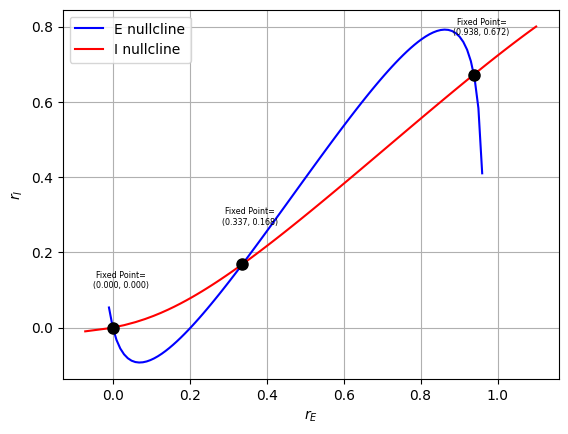

In [ ]:
pars = default_pars()
my_plot_nullcline(pars)

# Find the first fixed point
x_fp_1 = my_fp(pars, 0.1, 0.1)
if check_fp(pars, x_fp_1):
    plot_fp(x_fp_1)

# Find the second fixed point
x_fp_2 = my_fp(pars, 0.3, 0.3)
if check_fp(pars, x_fp_2):
    plot_fp(x_fp_2)

# Find the third fixed point
x_fp_3 = my_fp(pars, 0.8, 0.6)
if check_fp(pars, x_fp_3):
    plot_fp(x_fp_3)

plt.grid('gray')
plt.show()

This graph shows the nullclines and fixed points of a Wilson-Cowan neural model, illustrating where excitatory (rE) and inhibitory (rI) activity reaches equilibrium. The blue and red curves represent the E and I nullclines, respectively, and their intersections (black dots) are the fixed points. These fixed points indicate stable or unstable steady states of the system, suggesting possible bistability or multistability in neural dynamics. 

## Find the Jacobian matrix (linearization around the fixed points)

Your code computes the Jacobian matrix of the Wilson-Cowan model at each fixed point to analyze stability by calculating eigenvalues. The Jacobian matrix, derived from partial derivatives, determines how small perturbations evolve near equilibrium. If all eigenvalues have negative real parts, the fixed point is stable; if any have a positive real part, it is unstable. The script evaluates eigenvalues for three fixed points and classifies them accordingly, helping understand the stability and dynamics of excitatory-inhibitory interactions in the neural system

In [ ]:
def get_eig_Jacobian(fp,tau_E, a_E, theta_E, wEE, wEI, I_ext_E,
                     tau_I, a_I, theta_I, wIE, wII, I_ext_I, **other_pars):
    """
    Compute eigenvalues of the Wilson-Cowan Jacobian matrix at fixed point.
    """
    # Initialization
    rE, rI = fp
    J = np.zeros((2, 2))

    # Compute the four elements of the Jacobian matrix
    J[0, 0] = (-1 + wEE * dF(wEE * rE - wEI * rI + I_ext_E,a_E, theta_E)) / tau_E

    J[0, 1] = (-wEI * dF(wEE * rE - wEI * rI + I_ext_E, a_E, theta_E)) / tau_E

    J[1, 0] = (wIE * dF(wIE * rE - wII * rI + I_ext_I,a_I, theta_I)) / tau_I

    J[1, 1] = (-1 - wII * dF(wIE * rE - wII * rI + I_ext_I,a_I, theta_I)) / tau_I

    # Compute and return the eigenvalues
    evals = np.linalg.eig(J)[0]
    return evals


# Compute eigenvalues of Jacobian   
# we have to differentiate the cionditions for different initial conditions. 
eig_1 = get_eig_Jacobian(x_fp_1, **pars)
eig_2 = get_eig_Jacobian(x_fp_2, **pars)
eig_3 = get_eig_Jacobian(x_fp_3, **pars)

print(eig_1, 'Stable point')
print(eig_2, 'Unstable point')
print(eig_3, 'Stable point')

[-0.62338386+0.13110957j -0.62338386-0.13110957j] Stable point
[ 1.05720798 -0.87266898] Unstable point
[-0.95956219 -1.42197413] Stable point


this is the eigenvalue solution for eahc of the three points.in the first the real part is negative and so we are in a stable point. the seond is an unstable point, sinc ethe first eigen value is positive and the second is negative, and the last one has no complex part, and both eigen values are negative and so i can  consider it to be a stable point.  

## Parameters variation

The function plot_nullcline_diffw generates plots of nullclines and simulates the activity of excitatory (E) and inhibitory (I) populations in a neural network, while varying the synaptic weights w EE, w IE, w EI, and wII. It calculates the nullclines for each population and visualizes them along with the network's dynamics for different initial conditions of activity. The interactive sliders provided by widgets.interact allow real-time adjustment of these synaptic weights to explore their effects on the nullclines and population activity.

In [ ]:
def plot_nullcline_diffw(wEE,wIE,wEI,wII):
    """
    Plot nullclines for different values of the parameters
    """

    pars = default_pars(wEE=wEE,wIE=wIE,wII=wII,wEI=wEI)
    pars['rE_init']=0.6
    pars['rI_init']=0.6
    # plot the E, I nullclines
    Exc_null_rE = np.linspace(-0.01, .96, 100)
    Exc_null_rI = get_E_nullcline(Exc_null_rE, **pars)

    Inh_null_rI = np.linspace(-.01, .8, 100)
    Inh_null_rE = get_I_nullcline(Inh_null_rI, **pars)

    plt.figure(figsize=(12, 5.5))
    plt.subplot(121)
    plt.plot(Exc_null_rE, Exc_null_rI, 'b', label='E nullcline')
    plt.plot(Inh_null_rE, Inh_null_rI, 'r', label='I nullcline')
    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')
    plt.legend(loc='best')

    print('Initial conditions for the phase plane [rE,rI]:',pars['rE_init'],pars['rI_init'])

    plt.subplot(222)
    pars['rE_init'], pars['rI_init'] = 0.2, 0.2
    rE, rI = simulate_wc(**pars)
    plt.plot(pars['range_t'], rE, 'b', label='E population', clip_on=False)
    plt.plot(pars['range_t'], rI, 'r', label='I population', clip_on=False)
    plt.ylabel('Activity')
    plt.legend(loc='best')
    plt.ylim(-0.05, 1.05)
    plt.title('E/I activity\nfor different initial conditions',fontweight='bold')

    plt.subplot(224)
    pars['rE_init'], pars['rI_init'] = 0.4, 0.1
    rE, rI = simulate_wc(**pars)
    plt.plot(pars['range_t'], rE, 'b', label='E population', clip_on=False)
    plt.plot(pars['range_t'], rI, 'r', label='I population', clip_on=False)
    plt.xlabel('t (ms)')
    plt.ylabel('Activity')
    plt.legend(loc='best')
    plt.ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.grid()
    plt.show()


_ = widgets.interact(plot_nullcline_diffw, wEE=(9., 9., .01),wIE=(13., 13., .01),
                     wEI=(4., 4., .01),wII=(11., 11., .01))




interactive(children=(FloatSlider(value=9.0, description='wEE', max=9.0, min=9.0, step=0.01), FloatSlider(valu…

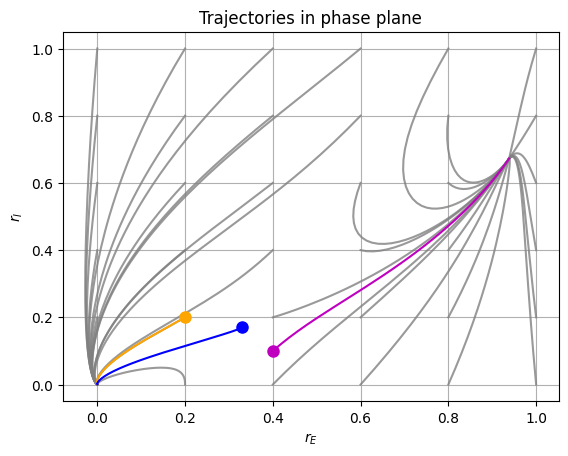

In [ ]:
x_init= [0.3,0.3]
#my_plot_trajectory(pars, 'red', x_init, '1')
my_plot_trajectories(pars, 0.2, 6,
                       'Sample trajectories \nfor different init. conditions')
my_plot_trajectory(pars, 'orange', [0.2, 0.2],
                     'Sample trajectory for \nlow activity')
my_plot_trajectory(pars, 'm', [0.4, 0.1],
                     'Sample trajectory for \nhigh activity')
my_plot_trajectory(pars, 'b', [0.33, 0.17],
                     'Sample trajectory for \nhigh activity')

plt.title('Trajectories in phase plane')
plt.grid('gray')
plt.show()


different starting conditions can given me differnet results. i can do many simulations starting from differnet points in our systems. i can see that there are two sub spaces, all the trajectory that are in the left part are converging to the point 0, 0. the trajectories are converging to the point 0.9, and 0.6. 
if i impose a good balance of weights between inibition and excitation, i will find the oscillatory behaviour. i have activated externally the excitatory population, given an excitatory external input and i have then to find the right weight for the balance between the excitation and the inibition. 


###### Set parameters to see oscillations

The code simulates and visualizes the activity of excitatory (E) and inhibitory (I) populations in a neural network. Parameters such as synaptic weights, external input to the excitatory population, and initial activity conditions are set. The simulation is then run to obtain the time series of activity for both populations, which are plotted over time. The result is a graph showing how the activity of both excitatory and inhibitory populations evolves over time, allowing observation of the network's dynamics under the defined conditions.

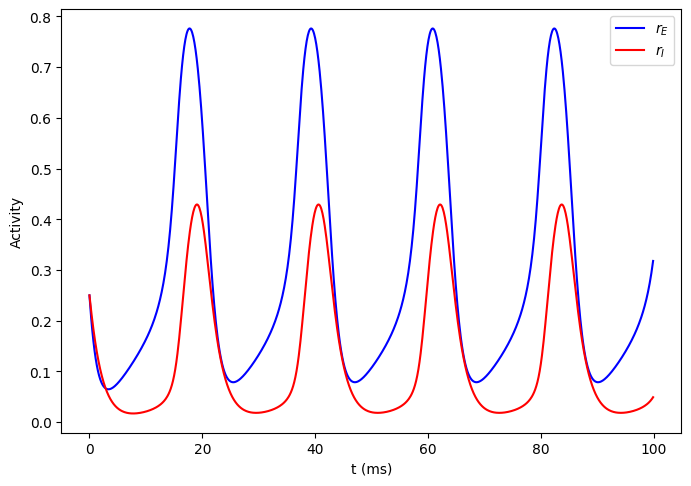

In [ ]:
pars = default_pars(T=100.)
pars['wEE'], pars['wEI'] = 6.4, 4.8
pars['wIE'], pars['wII'] = 6.0, 1.2
pars['I_ext_E'] = 0.8
pars['rE_init'], pars['rI_init'] = 0.25, 0.25

rE, rI = simulate_wc(**pars)
plt.figure(figsize=(8, 5.5))
plt.plot(pars['range_t'], rE, 'b', label=r'$r_E$')
plt.plot(pars['range_t'], rI, 'r', label=r'$r_I$')
plt.xlabel('t (ms)')
plt.ylabel('Activity')
plt.legend(loc='best')
plt.show()

## Visualize limit cycle in the phase plane

The code visualizes the dynamics of a neural network in the phase plane, specifically focusing on the limit cycles and fixed points. It first sets up parameters such as synaptic weights and external input, then plots the nullclines using the function my_plot_nullcline. It proceeds by finding a fixed point using my_fp, verifying its stability with check_fp, and plotting it if valid. The code then simulates and visualizes sample trajectories of the system from different initial conditions, showing how the network evolves over time. Additionally, it plots the vector field of the system with my_plot_vector, providing a comprehensive view of the phase plane with fixed points, trajectories, and vector field to analyze the system's dynamics.

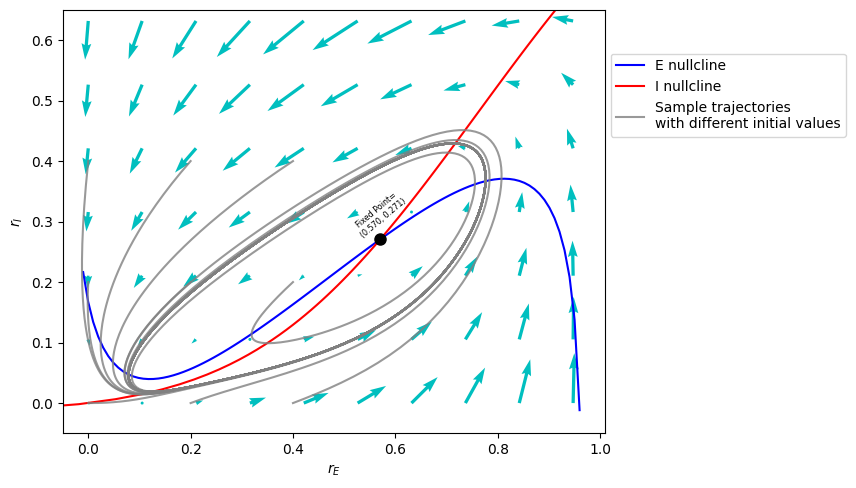

In [ ]:
# @markdown Execute to visualize phase plane
pars = default_pars(T=100.)
pars['wEE'], pars['wEI'] = 6.4, 4.8
pars['wIE'], pars['wII'] = 6.0, 1.2
pars['I_ext_E'] = 0.8


plt.figure(figsize=(7, 5.5))
my_plot_nullcline(pars)

# Find the correct fixed point
x_fp_1 = my_fp(pars, 0.8, 0.8)
if check_fp(pars, x_fp_1):
    plot_fp(x_fp_1, position=(0, 0), rotation=40)

my_plot_trajectories(pars, 0.2, 3,
                      'Sample trajectories \nwith different initial values')

my_plot_vector(pars)

plt.legend(loc=[1.01, 0.7])
plt.xlim(-0.05, 1.01)
plt.ylim(-0.05, 0.65)
plt.show()

i can find that there are trajectories actrattive, that can come back to this limit cycle. when we have this set of parameters, thewre is only a fixed point. and this fixed point is not stable but the dynamical behaviour is not un stalbe itself, because we have oscillations. basically the vector field is not converging anymore to a point but is converging to a limit cycle. a closure. it is a condition between a stable fixed point and complete unstability. it is not repulsive, but neither a fixed point. the arrow are the vector fields. to represen t the arrow what i have to do is to comput efor eahc initial conditon the value of the derivative. 

## Visualize the formation of the limit cycle (bifurcation)

In [ ]:
def time_constant_effect(tau_i=0.5):
    pars = default_pars(T=100.)
    pars['wEE'], pars['wEI'] = 6.4, 4.8
    pars['wIE'], pars['wII'] = 6.0, 1.2
    pars['I_ext_E'] = 0.8
    pars['tau_I'] = tau_i

    Exc_null_rE = np.linspace(0.0, .9, 100)
    Inh_null_rI = np.linspace(0.0, .6, 100)

    Exc_null_rI = get_E_nullcline(Exc_null_rE, **pars)
    Inh_null_rE = get_I_nullcline(Inh_null_rI, **pars)

    plt.figure(figsize=(12.5, 5.5))

    plt.subplot(121)  # nullclines
    plt.plot(Exc_null_rE, Exc_null_rI, 'b', label='E nullcline', zorder=2)
    plt.plot(Inh_null_rE, Inh_null_rI, 'r', label='I nullcline', zorder=2)
    plt.xlabel(r'$r_E$')
    plt.ylabel(r'$r_I$')

    # fixed point
    x_fp_1 = my_fp(pars, 0.5, 0.5)
    plt.plot(x_fp_1[0], x_fp_1[1], 'ko', zorder=2)
    eig_1 = get_eig_Jacobian(x_fp_1, **pars)

    # trajectories
    for ie in range(5):
        for ii in range(5):
            pars['rE_init'], pars['rI_init'] = 0.1 * ie, 0.1 * ii
            rE_tj, rI_tj = simulate_wc(**pars)
            plt.plot(rE_tj, rI_tj, 'k', alpha=0.3, zorder=1)

    # vector field
    EI_grid_E = np.linspace(0., 1.0, 20)
    EI_grid_I = np.linspace(0., 0.6, 20)
    rE, rI = np.meshgrid(EI_grid_E, EI_grid_I)
    drEdt, drIdt = EIderivs(rE, rI, **pars)
    n_skip = 2
    plt.quiver(rE[::n_skip, ::n_skip], rI[::n_skip, ::n_skip],
              drEdt[::n_skip, ::n_skip], drIdt[::n_skip, ::n_skip],
              angles='xy', scale_units='xy', scale=10, facecolor='c')
    plt.title(r'$\tau_I=$'+'%.1f ms' % tau_i)

    plt.subplot(122)  # sample E/I trajectories
    pars['rE_init'], pars['rI_init'] = 0.25, 0.25
    rE, rI = simulate_wc(**pars)
    plt.plot(pars['range_t'], rE, 'b', label=r'$r_E$')
    plt.plot(pars['range_t'], rI, 'r', label=r'$r_I$')
    plt.xlabel('t (ms)')
    plt.ylabel('Activity')
    plt.title(r'$\tau_I=$'+'%.1f ms' % tau_i)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


_ = widgets.interact(time_constant_effect, tau_i=(0.2, 3, .1))

interactive(children=(FloatSlider(value=0.5, description='tau_i', max=3.0, min=0.2), Output()), _dom_classes=(…

In [ ]:
def get_dGdE(fp, tau_E, a_E, theta_E, wEE, wEI, I_ext_E, **other_pars):
    """
    Compute dGdE
    Args:
        fp   : fixed point (E, I), array
        Other arguments are parameters of the Wilson-Cowan model
    Returns:
        J    : the 2x2 Jacobian matrix
    """
    rE, rI = fp

    # Calculate the J[0,0]
    dGdrE = (-1 + wEE * dF(wEE * rE - wEI * rI + I_ext_E, a_E, theta_E)) / tau_E

    return dGdrE


# Get fixed points
pars = default_pars()
x_fp_1 = my_fp(pars, 0.1, 0.1)
x_fp_2 = my_fp(pars, 0.3, 0.3)
x_fp_3 = my_fp(pars, 0.8, 0.6)

# Compute dGdE
dGdrE1 = get_dGdE(x_fp_1, **pars)
dGdrE2 = get_dGdE(x_fp_2, **pars)
dGdrE3 = get_dGdE(x_fp_3, **pars)

print(f'For the default case:')
print(f'dG/drE(1) = {dGdrE1:.3f}')
print(f'dG/drE(2) = {dGdrE2:.3f}')
print(f'dG/drE(3) = {dGdrE3:.3f}')

print('\n')

pars = default_pars(wEE=6.4, wEI=4.8, wIE=6.0, wII=1.2, I_ext_E=0.8)
x_fp_lc = my_fp(pars, 0.8, 0.8)

dGdrE_lc = get_dGdE(x_fp_lc, **pars)

print('For the limit cycle case:')
print(f'dG/drE(limit_cycle) = {dGdrE_lc:.3f}')

For the default case:
dG/drE(1) = -0.650
dG/drE(2) = 1.519
dG/drE(3) = -0.706


For the limit cycle case:
dG/drE(limit_cycle) = 0.837


In [ ]:
pars = default_pars(T=50., dt=0.1)
pars['wEE'], pars['wEI'] = 6.4, 4.8
pars['wIE'], pars['wII'] = 6.0, 1.2
pars['I_ext_E'] = 0.8
pars['tau_I'] = 0.8


def ISN_I_perturb(dI=0.1):
    Lt = len(pars['range_t'])
    pars['I_ext_I'] = np.zeros(Lt)
    pars['I_ext_I'][int(Lt / 2):] = dI

    pars['rE_init'], pars['rI_init'] = 0.6, 0.26
    rE, rI = simulate_wc(**pars)

    plt.figure(figsize=(8, 1.5))

    plt.plot(pars['range_t'], pars['I_ext_I'], 'k')
    plt.xlabel('t (ms)')
    plt.ylabel(r'$I_I^{\mathrm{ext}}$')
    plt.ylim(pars['I_ext_I'].min() - 0.01, pars['I_ext_I'].max() + 0.01)
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.plot(pars['range_t'], rE, 'b', label=r'$r_E$')
    plt.plot(pars['range_t'], rE[int(Lt / 2) - 1] * np.ones(Lt), 'b--')
    plt.plot(pars['range_t'], rI, 'r', label=r'$r_I$')
    plt.plot(pars['range_t'], rI[int(Lt / 2) - 1] * np.ones(Lt), 'r--')
    plt.ylim(0, 0.8)
    plt.xlabel('t (ms)')
    plt.ylabel('Activity')
    plt.legend(loc='best')
    plt.show()


_ = widgets.interact(ISN_I_perturb, dI=(-0.2, 0.21, .05))

interactive(children=(FloatSlider(value=0.1, description='dI', max=0.21, min=-0.2, step=0.05), Output()), _dom…